# EDA — Exploration SQL

**Pourquoi commencer par le déséquilibre de classes ?**

Dans ce dataset, les fraudes représentent environ 0,17% des transactions (~492 sur 284807). C'est un **dataset fortement déséquilibré**.

Ça détermine presque tous les choix qu'on va faire ensuite :
- **L'accuracy est trompeuse** : un modèle qui prédit "pas de fraude" pour TOUTE transaction, sans jamais rien apprendre, aurait déjà ~99,83% d'accuracy. Il serait inutile (0 fraude détectée) mais afficherait un score qui a l'air excellent.
- On doit donc utiliser des métriques adaptées au déséquilibre : **recall** (combien de fraudes réelles sont détectées), **precision** (parmi les alertes, combien sont de vraies fraudes), **ROC-AUC** et surtout **PR-AUC** (plus informative que ROC-AUC quand la classe positive est rare).
- Ça justifie aussi **SMOTE** plus tard : sans rééquilibrage, un modèle entraîné sur ces données a très peu d'exemples de fraude pour apprendre le pattern.

D'où l'ordre : on mesure le déséquilibre AVANT de faire quoi que ce soit d'autre, pour savoir à quoi s'attendre et pourquoi les choix suivants (métriques, SMOTE) sont nécessaires.

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text

# Connexion à la base créée par src/data/load_data.py
engine = create_engine("sqlite:///../data/processed/fraud.db")

## 1. Répartition fraude / non-fraude

`Class` = 1 pour une fraude, 0 sinon. `GROUP BY` + `COUNT` pour compter chaque catégorie,
et un calcul de pourcentage pour visualiser l'ampleur du déséquilibre.

In [2]:
query_balance = text("""
    SELECT
        Class,
        COUNT(*) AS nb_transactions,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM transactions), 4) AS pourcentage
    FROM transactions
    GROUP BY Class
""")

pd.read_sql(query_balance, engine)

,Class,nb_transactions,pourcentage
0,0,284315,99.8273
1,1,492,0.1727


## 2. Valeurs manquantes

On vérifie ça avant toute analyse : des valeurs manquantes non gérées peuvent fausser des stats
ou faire planter l'entraînement des modèles plus tard.

Ici on charge toute la table en pandas (elle est petite : ~285000 lignes, ça tient largement en mémoire)
et on utilise `isnull().sum()`, la méthode standard pandas pour ça — beaucoup plus simple à lire
qu'une requête SQL équivalente.

In [3]:
df = pd.read_sql(text("SELECT * FROM transactions"), engine)

# .isnull() transforme chaque cellule en True (manquante) ou False (présente).
# .sum() additionne ensuite ces True/False colonne par colonne
# (Python compte True comme 1 et False comme 0) -> total de valeurs manquantes par colonne.
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## 3. Statistiques de base sur Amount et Time

`Amount` = montant de la transaction, `Time` = secondes écoulées depuis la première transaction du dataset.
On regarde min/max/moyenne pour repérer d'éventuelles valeurs aberrantes (montants négatifs ou énormes)
et pour comparer ces stats entre fraudes et non-fraudes : si les fraudes ont des montants typiquement
différents, c'est un signal utile pour les modèles.

In [4]:
query_stats = text("""
    SELECT
        Class,
        COUNT(*) AS nb,
        MIN(Amount) AS amount_min,
        MAX(Amount) AS amount_max,
        ROUND(AVG(Amount), 2) AS amount_moyen,
        MIN(Time) AS time_min,
        MAX(Time) AS time_max
    FROM transactions
    GROUP BY Class
""")

pd.read_sql(query_stats, engine)

,Class,nb,amount_min,amount_max,amount_moyen,time_min,time_max
0,0,284315,0.0,25691.16,88.29,0.0,172792.0
1,1,492,0.0,2125.87,122.21,406.0,170348.0


## 4. Visualisation avec pandas / matplotlib

On a déjà les chiffres (SQL), on passe maintenant aux graphiques pour "voir" ce que ça donne.
On réutilise le `df` déjà chargé en mémoire (cellule 2) — inutile de refaire une requête SQL,
pandas + matplotlib suffisent à partir d'ici.

**Pourquoi une échelle logarithmique pour `Amount` ?** La grande majorité des transactions ont
un petit montant, et quelques-unes ont un montant très élevé. Sur un histogramme classique,
ces rares grosses valeurs écrasent le graphique et on ne voit plus rien pour les petits montants.
L'échelle log "compresse" les grandes valeurs pour que la distribution reste lisible.

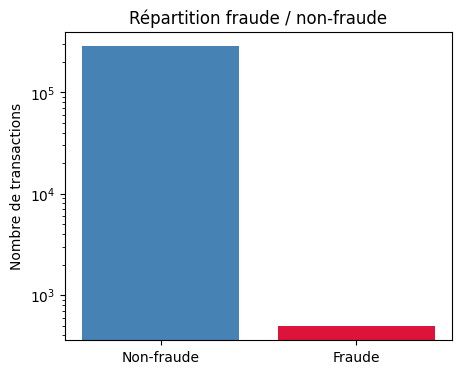

In [5]:
import matplotlib.pyplot as plt

counts = df["Class"].value_counts().sort_index()  # index 0 = non-fraude, 1 = fraude

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Non-fraude", "Fraude"], counts, color=["steelblue", "crimson"])
ax.set_ylabel("Nombre de transactions")
ax.set_title("Répartition fraude / non-fraude")

# Échelle log sur l'axe Y : sans ça, la barre "fraude" (492) est quasi invisible
# à côté de la barre "non-fraude" (284315) — l'échelle log garde les deux lisibles.
ax.set_yscale("log")
plt.show()

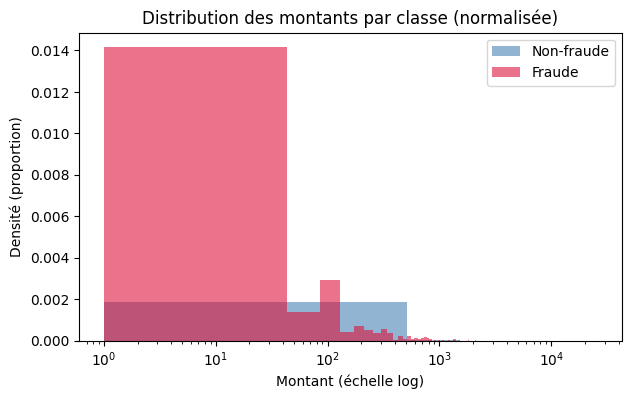

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

# density=True : on affiche une proportion (aire sous la courbe = 1) au lieu du nombre
# brut de transactions. Indispensable ici car il y a 284315 non-fraudes pour seulement
# 492 fraudes -> en comptage brut, la courbe "Fraude" serait invisible, écrasée à 0.
# +1 avant le log : Amount peut valoir 0, et log(0) n'existe pas.
ax.hist(df.loc[df["Class"] == 0, "Amount"] + 1, bins=50, alpha=0.6, density=True, label="Non-fraude", color="steelblue")
ax.hist(df.loc[df["Class"] == 1, "Amount"] + 1, bins=50, alpha=0.6, density=True, label="Fraude", color="crimson")

ax.set_xscale("log")
ax.set_xlabel("Montant (échelle log)")
ax.set_ylabel("Densité (proportion)")
ax.set_title("Distribution des montants par classe (normalisée)")
ax.legend()
plt.show()